## Homework 02

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("car_fuel_efficiency_2026.csv")

In [3]:
df = data[["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]].copy()

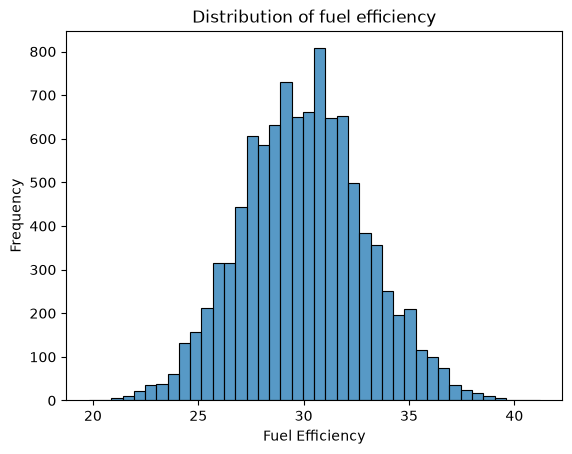

In [4]:
# EDA

sns.histplot(df.fuel_efficiency_mpg, bins = 40)
plt.xlabel("Fuel Efficiency")
plt.ylabel("Frequency")
plt.title("Distribution of fuel efficiency")
plt.show()

# No it does no have a long tail

In [5]:
# Question 1:
df.isnull().sum()

# The column "horsepower" has null values

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
# Question 2:
print(df.horsepower.median())

254.0


In [8]:
# Prepare and split the dataset
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [9]:
# filling with zero
df_train_zero_filled = df_train.copy()
df_val_zero_filled = df_val.copy()
df_test_zero_filled = df_test.copy()

In [12]:
df_train_zero_filled.fillna({"horsepower": 0}, inplace=True)
df_val_zero_filled.fillna({"horsepower": 0}, inplace=True)
df_test_zero_filled.fillna({"horsepower": 0}, inplace=True)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
399,2370,268.0,4410,1981,27.8
7247,2240,256.0,4220,2020,37.3
6406,2090,217.0,3910,2023,33.1
882,2280,251.0,4420,2021,31.3
3565,2450,256.0,4420,1979,26.4
...,...,...,...,...,...
5734,2100,257.0,4130,1988,30.7
5191,2160,231.0,4180,2000,25.5
5390,2430,246.0,4660,2013,30.1
860,2450,307.0,4500,2014,30.5


In [13]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [14]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [21]:
df_train_zero_filled

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,0.0,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,0.0,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [28]:
X_train = df_train_zero_filled.drop(["fuel_efficiency_mpg"], axis = 1).values
y_train = df_train_zero_filled["fuel_efficiency_mpg"]

In [29]:
w0, w = train_linear_regression(X_train, y_train)

In [30]:
X_val = df_val_zero_filled.drop(["fuel_efficiency_mpg"], axis = 1).values
y_val = df_val_zero_filled["fuel_efficiency_mpg"]

In [31]:
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(2.20529319475341)

In [32]:
# filling using the mean
mean_target = df_train.fuel_efficiency_mpg.mean()

In [33]:
# filling with the train mean
df_train_mean_filled = df_train.copy()
df_val_mean_filled = df_val.copy()
df_test_mean_filled = df_test.copy()

In [34]:
df_train_mean_filled.fillna({"horsepower": mean_target}, inplace=True)
df_val_mean_filled.fillna({"horsepower": mean_target}, inplace=True)
df_test_mean_filled.fillna({"horsepower": mean_target}, inplace=True)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
399,2370,268.0,4410,1981,27.8
7247,2240,256.0,4220,2020,37.3
6406,2090,217.0,3910,2023,33.1
882,2280,251.0,4420,2021,31.3
3565,2450,256.0,4420,1979,26.4
...,...,...,...,...,...
5734,2100,257.0,4130,1988,30.7
5191,2160,231.0,4180,2000,25.5
5390,2430,246.0,4660,2013,30.1
860,2450,307.0,4500,2014,30.5


In [35]:
X_train_filled = df_train_mean_filled.drop(["fuel_efficiency_mpg"], axis = 1).values
y_train_filled = df_train_mean_filled["fuel_efficiency_mpg"]

In [36]:
w0, w = train_linear_regression(X_train_filled, y_train_filled)

In [37]:
X_val = df_val_mean_filled.drop(["fuel_efficiency_mpg"], axis = 1).values
y_val = df_val_mean_filled["fuel_efficiency_mpg"]

In [38]:
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(2.2051562666797455)

In [39]:
# so zero filled is better

In [ ]:
# Question 4
